# Определение возраста покупателей

Сетевой супермаркет «Хлеб-Соль» внедряет систему компьютерного зрения для обработки фотографий покупателей. Фотофиксация в прикассовой зоне поможет определять возраст клиентов, чтобы:

- Анализировать покупки и предлагать товары, которые могут заинтересовать покупателей этой возрастной группы;
- Контролировать добросовестность кассиров при продаже алкоголя.

**Цель:** Построить модель, которая по фотографии определит приблизительный возраст человека. В вашем распоряжении набор фотографий людей с указанием возраста.

**Задачи:**
- Провести исследовательский анализ набора фотографий.
- Подготовить данные к обучению.
- Обучить нейронную сеть и рассчитайте её качество.

## Исследовательский анализ данных

In [1]:
# Импорты
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
# Загрузим картинки и метки
labels = pd.read_csv('/datasets/faces/labels.csv')

train_datagen = ImageDataGenerator(rescale=1./255)

train_gen_flow = train_datagen.flow_from_dataframe(
        dataframe=labels,
        directory='/datasets/faces/final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=32,
        class_mode='raw',
        seed=12345)

Found 7591 validated image filenames.


In [3]:
labels

,file_name,real_age
0,000000.jpg,4
1,000001.jpg,18
2,000002.jpg,80
3,000003.jpg,50
4,000004.jpg,17
...,...,...
7586,007608.jpg,14
7587,007609.jpg,37
7588,007610.jpg,28
7589,007611.jpg,20


In [4]:
# посмотрим все ли картинки загрузились
train_gen_flow.samples

7591

- В датасете две колонки:
 - `file_name` содержит название файла с картинкой.
 - `real_age` сожержит возраст (целевой признак), целое число лет
 
Все картинки (7591) загрузились нормально.

In [5]:
labels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7591 entries, 0 to 7590
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   file_name  7591 non-null   object
 1   real_age   7591 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 118.7+ KB


In [6]:
labels.describe()

,real_age
count,7591.000000
mean,31.201159
std,17.145060
min,1.000000
25%,20.000000
50%,29.000000
75%,41.000000
max,100.000000


Статистика по возрастам выглядит адекватно:
   - возраст людей в граница от 1 до 100 лет
   - средний возраст составляет 31 год, медианный возраст - 29 лет.
   - половина всех людей в выборке в возрасте от 20 до 41 года.

In [7]:
labels.isna().sum()

file_name    0
real_age     0
dtype: int64

In [8]:
labels.duplicated().sum()

0

In [9]:
labels.duplicated('file_name').sum()

0

Пропуски и дубликаты в данных отсутствуют.

Посмотрим внимательней на распределение данных по возрасту на графиках.

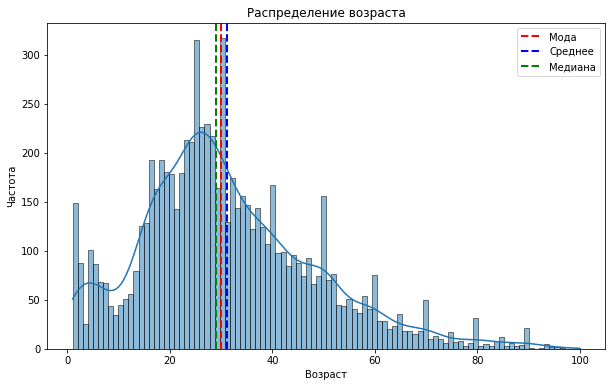

In [10]:
# Настройка внешнего вида графика
plt.figure(figsize=(10, 6))
sns.histplot(labels['real_age'], bins=100, kde=True)  # kde=True добавляет кривую плотности

# Вычисление моды, среднего и медианы
mode_age = labels['real_age'].mode()[0]
mean_age = labels['real_age'].mean()
median_age = labels['real_age'].median()

# Добавление вертикальных линий для моды, среднего и медианы
plt.axvline(mode_age, color='red', linestyle='dashed', linewidth=2, label='Мода')
plt.axvline(mean_age, color='blue', linestyle='dashed', linewidth=2, label='Среднее')
plt.axvline(median_age, color='green', linestyle='dashed', linewidth=2, label='Медиана')

# Добавление заголовка и меток
plt.title('Распределение возраста')
plt.xlabel('Возраст')
plt.ylabel('Частота')

# Добавление легенды
plt.legend()

# Показать график
plt.show()

В целом, данные по возрастам распределены нормально, за исключением небольшого пика в районе 1-10 лет. Вероятно, родители очень любят выкладывать фотографии своих малышей и поэтому данных по ним собралось больше.

Пик на уровне 1 года выглядит подозрительно. Когда будем анализировать картинки, лучше на всякий случай убедиться, что в данных нету ошибки.

Мода, медиана и среднее находятся достаточно близко друг к другу, это говорит о том, что данные более менее сбалансированы. Но ближе всего к матожиданию распределения (вершина купола) находится медиана.

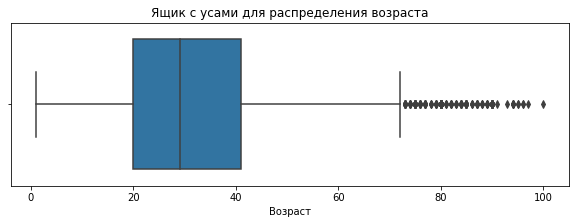

In [11]:
# Настройка внешнего вида графика
plt.figure(figsize=(10, 3))

# Построение ящика с усами
sns.boxplot(x=labels['real_age'])

# Добавление заголовка и меток
plt.title('Ящик с усами для распределения возраста')
plt.xlabel('Возраст')

# Показать график
plt.show()

"Ящик с усами" также не показывает аномалий. Единственное, на что можно обратить внимание, что людей возрастом старше 70-75 лет в выборке мало (ящик показывает их как выбросы), поэтому обученная модель может хуже распознавать людей в данной возрастной категории, чем остальных. 

In [12]:
# Извлечение изображений и меток
train_images, train_labels = next(train_gen_flow)

In [13]:
train_images[0].shape

(224, 224, 3)

Картинки имеют 3 канала (RGB).

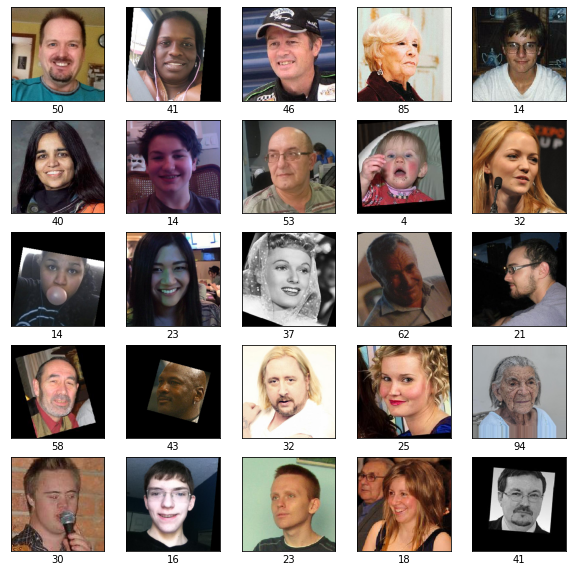

In [14]:
# Построение графика
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    plt.xlabel(train_labels[i])
plt.show()

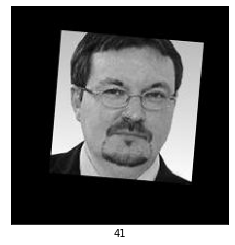

In [16]:
# Выведем чернобелую картинку
plt.xticks([])
plt.yticks([])
plt.grid(False)
plt.imshow(train_images[24])
plt.xlabel(train_labels[24])
plt.show()

In [17]:
train_images[24].shape

(224, 224, 3)

- Мы имеем дело с цветными картинками (но встречаются и черно-белые). Не смотря на это, все картинки имеют ровно 3 канала.
- Визуально картинки людей соответствуют указанному возрасту.

В выборку не попали младенцы возрастом 1 год, для проверки выведем несколько таких изображений тоже. 

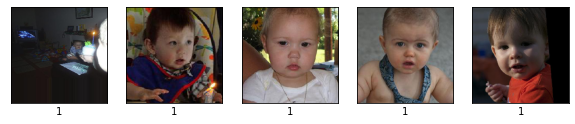

In [18]:
# Заранее установим количество нужных изображений
target_age = 1
target_count = 5

# Инициализируем резервуар для изображений и меток
images_with_age_1 = []
labels_with_age_1 = []

# Флаг для прекращения после нахождения нужного количества
found_count = 0

# Генерация изображений с метками
for images, ages in train_gen_flow:
    for i in range(len(ages)):
        if ages[i] == target_age:  # Проверяем метку
            images_with_age_1.append(images[i])
            labels_with_age_1.append(ages[i])
            found_count += 1
        if found_count >= target_count:  # Если нашли нужное количество, выходим
            break
    if found_count >= target_count:
        break

# Превращаем список изображений в массив NumPy
images_with_age_1 = np.array(images_with_age_1)

# Визуализация изображений
plt.figure(figsize=(10, 10))
for i in range(target_count):
    plt.subplot(1, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(images_with_age_1[i])
    plt.xlabel(labels_with_age_1[i])
plt.show()

Вроде с ними тоже все нормально, каках-то странностей не выявлено.

### Выводы

Выборка имеет 7591 картинку (цветные и черно-белые).

Все картинки были загружены в размерности (224, 224, 3). Явные пропуски и дубликаты в данных отсутствуют.

Возраст людей находится в интервале от 1 до 100 лет.

В целом данные распределены нормально, но людей возрастной категории 70+ достаточно мало, что может влиять на качество предсказаний модели для указанной возрастной категории.

**Модель:** При обучении модели мы будем решать задачу регрессии (предсказание возраста пользователя). Значит на последнем слое нейронной модели у нас скорей всего будет один нейрон с линейной активацией, чтобы предсказывать непрерывный числовой признак. Это позволяет модели выдавать непрерывные значения для возраста, что является необходимым для регрессии. При необходимости, из непрерывного числа лет мы всегда сможем получить целое чило лет путем извлечения целой части или округления. 


**Аугментация данных**: Для борьбы с нехваткой данных в возрастной категории 70+ можно использовать аугментацию данных. Это позволит создать дополнительные "новые" изображения на основе уже существующих, изменяя их (например, поворот, изменяя яркость, отражение и т.д.). Это может усилить вашу модель в недостаточно представленном классе.

**Метрики** Для оценки качества регрессионной модели можем использовать такие метрики, такие как **MAE** (средняя абсолютная ошибка). Это поможет понять, насколько точно модель предсказывает возраст.

## Обучение модели

Перенесите сюда код обучения модели и её результат вывода на экран.


(Код в этом разделе запускается в отдельном GPU-тренажёре, поэтому оформлен не как ячейка с кодом, а как код в текстовой ячейке)

```python

import numpy as np
import pandas as pd
from tensorflow.keras.layers import Dense, Conv2D, Flatten, AvgPool2D, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50


def load_train(path):
    labels = pd.read_csv(path + 'labels.csv')

    train_datagen = ImageDataGenerator(
        validation_split=0.25,
        rescale=1./255,
        horizontal_flip=True
    )
    
    train_gen_flow = train_datagen.flow_from_dataframe(
            dataframe=labels,
            directory=path + 'final_files/',
            x_col='file_name',
            y_col='real_age',
            target_size=(224, 224),
            batch_size=32,
            class_mode='raw',
            subset='training',
            seed=12345)
 
    return train_gen_flow
 
def load_test(path):
    labels = pd.read_csv(path + 'labels.csv')
    
    test_datagen = ImageDataGenerator(
        validation_split=0.25,
        rescale=1./255
    )
    
    test_gen_flow = test_datagen.flow_from_dataframe(
        dataframe=labels,
        directory=path + 'final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=32,
        class_mode='raw',
        subset='validation',
        seed=12345)
 
    return test_gen_flow
 
 
def create_model(input_shape):
 
    backbone = ResNet50(input_shape=input_shape,
                        weights='/datasets/keras_models/resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5', 
                        include_top=False)
    
    model = Sequential()
    model.add(backbone)
    model.add(GlobalAveragePooling2D())
    model.add(Dense(1, activation='relu'))
    model.compile(loss='mean_squared_error', optimizer=Adam(learning_rate=1e-5), metrics=['mae']) 
 
    return model
 
 
def train_model(model, train_data, test_data, batch_size=None, epochs=10,
                steps_per_epoch=None, validation_steps=None):
 
    model.fit(train_data,
              validation_data=test_data,
              batch_size=batch_size, 
              epochs=epochs,
              steps_per_epoch=steps_per_epoch,
              validation_steps=validation_steps,
              verbose=2)
 
    return model

```

```

Train for 178 steps, validate for 60 steps
Epoch 1/10
178/178 - 72s - loss: 820.9120 - mae: 24.1334 - val_loss: 874.9275 - val_mae: 24.7220
Epoch 2/10
178/178 - 61s - loss: 225.9912 - mae: 11.5454 - val_loss: 759.3256 - val_mae: 22.6400
Epoch 3/10
178/178 - 50s - loss: 104.4503 - mae: 7.6606 - val_loss: 797.8415 - val_mae: 23.3967
Epoch 4/10
178/178 - 50s - loss: 65.8656 - mae: 6.1605 - val_loss: 219.8664 - val_mae: 10.8956
Epoch 5/10
178/178 - 45s - loss: 47.7742 - mae: 5.2437 - val_loss: 103.3479 - val_mae: 7.9057
Epoch 6/10
178/178 - 46s - loss: 36.9613 - mae: 4.6584 - val_loss: 105.0519 - val_mae: 8.0409
Epoch 7/10
178/178 - 47s - loss: 29.2490 - mae: 4.1513 - val_loss: 89.0463 - val_mae: 7.1975
Epoch 8/10
178/178 - 54s - loss: 23.3942 - mae: 3.7316 - val_loss: 84.2527 - val_mae: 6.8613
Epoch 9/10
178/178 - 59s - loss: 20.1783 - mae: 3.4795 - val_loss: 80.5065 - val_mae: 6.6934
Epoch 10/10
178/178 - 59s - loss: 17.6926 - mae: 3.2519 - val_loss: 84.8107 - val_mae: 6.9592

60/60 - 12s - loss: 84.8107 - mae: 6.9592

```

## Анализ обученной модели

Для обучения использован предобученный ResNet50 с добавлением слоя глобального усреднения и одного выходного нейрона с линейной активацией ('relu'). Активацию 'linear' не использовали, чтобы избежать отрицательных предсказаний.

Модель обучалась на 10 эпохах с использованием метрики MAE (средняя абсолютная ошибка) и функции потерь МSE (среднеквадратичная ошибка).

Разница в значениях между обучающим и валидационным наборами MAE и Loss уменьшилась, но в последние эпохи можно заметить, что валидационная потеря и MAE начали колебаться. Кроме того, MAE На валидационном наборе практически в 2 раза превышает MAE на обучающей выборке.

Это может указывать на возможное переобучение модели в последних эпохах.

Тем не менее, модель прошла проверку на тестируемой выборке и ее можно использовать для предсказаний.